# Comparing Pedestal Models

Can we get away with fewer coefficients in our model?

The full-up model has the form:
$$
y = a + b t_{exp} \exp{T_{det0} / c} + d T_{det0} + e T_{det0}^2 + f T_{ADC},
$$
We want to know how few parameters we can reasonably get away with. We start by fixing $f$ per segment of the detector which we know yields nearly equivalent results to the full model.
We'll then steadily drop out parameters from the model and compare the pedestal-subtracted data in each case.
For these reduced parameter sets, we will only fit to points where the detector temperature was below zero.

In [1]:
import pathlib
import astropy.units as u
import xarray
import matplotlib.pyplot as plt
import numpy as np
import dask.array
import distributed
import scipy.stats

from astropy.visualization import ImageNormalize, AsymmetricPercentileInterval, LogStretch

In [2]:
#client = distributed.Client(address='tcp://127.0.0.1:41691')

In [3]:
data_dir = pathlib.Path('../data/moxsi_gsfc_calibration_images/')

In [4]:
ds = xarray.open_zarr(data_dir / 'images.zarr')
# Load a small chunk straight into memory. This chunk was selected to avoid the pinholes, alignment holes, and slots/slits
det_slice = np.s_[1275:1525, :]
ds = ds.isel(row=det_slice[0], column=det_slice[1]).compute()

In [5]:
da_coeffs_all = xarray.open_dataarray(data_dir / 'fit_coefficients.nc')[det_slice].compute()
da_coeffs_all_subzero = xarray.open_dataarray(data_dir / 'fit_coefficients_full_subzero.nc')[det_slice].compute()
da_coeffs_a = xarray.open_dataarray(data_dir / 'fit_coefficients_a_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_ad = xarray.open_dataarray(data_dir / 'fit_coefficients_ad_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_abcd = xarray.open_dataarray(data_dir / 'fit_coefficients_adbc_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_ade = xarray.open_dataarray(data_dir / 'fit_coefficients_ade_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_a_fixed_d = xarray.open_dataarray(data_dir / 'fit_coefficients_a_fixed_d_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_ad_warm = xarray.open_dataarray(data_dir / 'fit_coefficients_ad_fixed_f_all_temperatures.nc')[det_slice].compute()
da_coeffs_abd = xarray.open_dataarray(data_dir / 'fit_coefficients_adb_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_a_fixed_bcdef = xarray.open_dataarray(data_dir / 'fit_coefficients_a_fixed_bcdef_all_temperatures.nc')[det_slice].compute()


Below are the maps of the parameters for the full model.

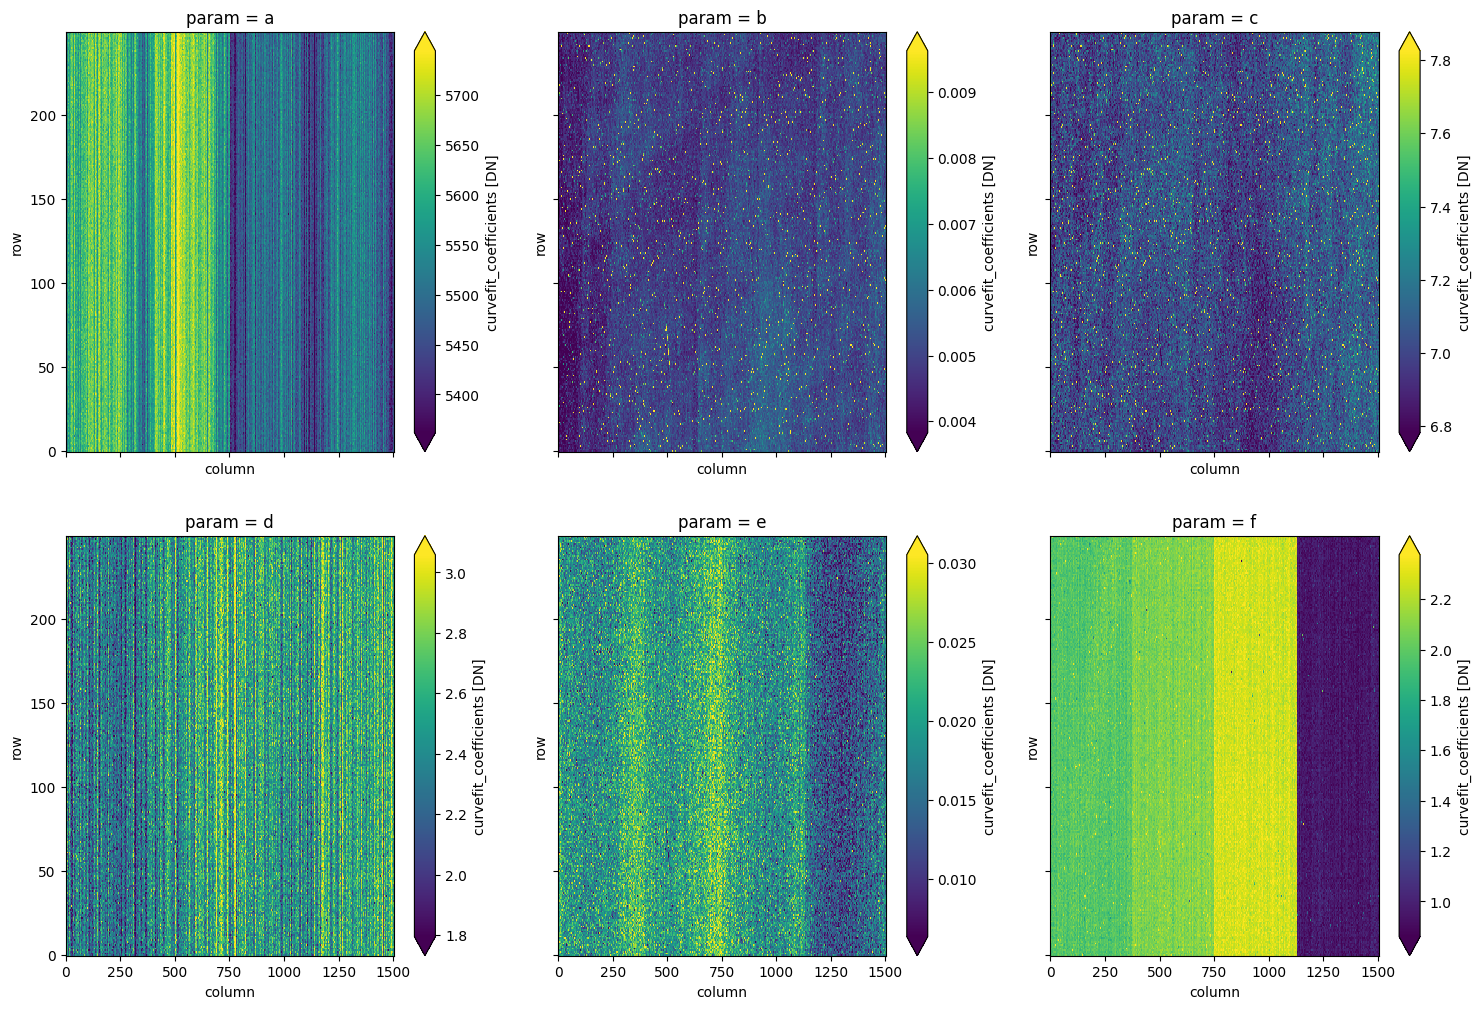

In [6]:
size = 6 
fig,axes = plt.subplots(2,3,figsize=(size*3,size*2),sharex=True,sharey=True)
for i,ax in enumerate(axes.flatten()):
    vmin, vmax = AsymmetricPercentileInterval(1,99).get_limits(da_coeffs_all[...,i].data)
    da_coeffs_all[...,i].plot.imshow(ax=ax, vmin=max(0,vmin), vmax=vmax)

In [7]:
range_dict = {'a': [5200,6000], 'b': [0.0005, 0.01], 'c': [5,10.0], 'd': [0.5,5], 'e': [0.002,0.07], 'f': [0.5,3.0]}

Next, compare the distribution of fit parameters for all cases.

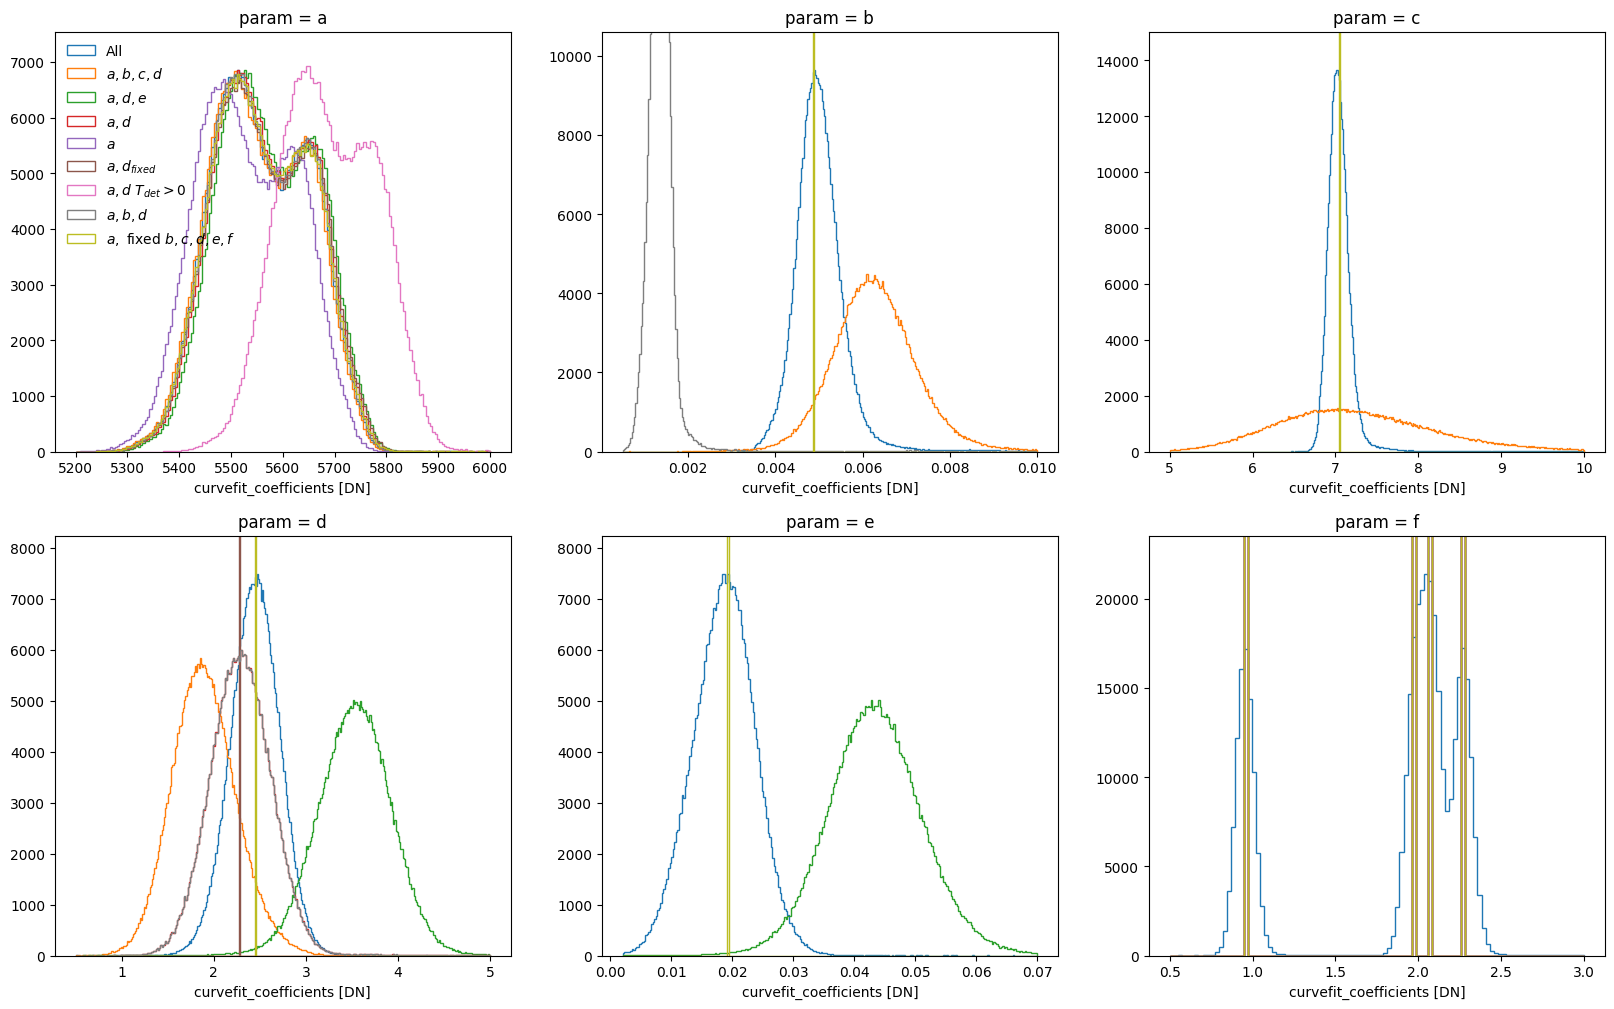

In [8]:
fig,axes = plt.subplots(2,3,figsize=(20,12),sharex=False,sharey=False)
bin_edges = {}
for i,(ax,param) in enumerate(zip(axes.flatten(),da_coeffs_all.param.data)):
    if (range := range_dict.get(str(param))) is None:
        range = AsymmetricPercentileInterval(0.5,99.5).get_limits(da_coeffs_all[...,i].data)
    h_all, be, _ = da_coeffs_all.sel(param=param).plot.hist(ax=ax, bins='scott', range=range, histtype='step', log=False, label='All', color='C0')
    #_ = da_coeffs_all_subzero.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label='All subzero', color='C1')
    if param in da_coeffs_abcd.param:
        _ = da_coeffs_abcd.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,b,c,d$', color='C1')
    if param in da_coeffs_ade.param:
        _ = da_coeffs_ade.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,d,e$', color='C2')
    if param in da_coeffs_ad.param:
        _ = da_coeffs_ad.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,d$', color='C3')
    if param in da_coeffs_a.param:
        _ = da_coeffs_a.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a$', color='C4')
    if param in da_coeffs_a_fixed_d.param:
        _ = da_coeffs_a_fixed_d.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a, d_{fixed}$', color='C5')
    if param in da_coeffs_ad_warm.param:
        _ = da_coeffs_ad_warm.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,d$ $T_{det}>0$', color='C6')
    if param in da_coeffs_abd.param:
        _ = da_coeffs_abd.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,b,d$', color='C7')
    _ = da_coeffs_a_fixed_bcdef.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,$ fixed $b,c,d,e,f$', color='C8')
    #if param == 'f':
    #    ax.set_ylim(0,2.5e4)
    #if param == 'd':
    #    ax.set_ylim(0,7600)
    ax.set_ylim(0, 1.1*h_all.max())
    if param == 'a':
        ax.legend(loc=2, frameon=False)
    #bin_edges[str(da_coeffs_full.param[i].data)] = be
    #vmin, vmax = AsymmetricPercentileInterval(0.5,99).get_limits(da_coeffs[...,i].data)
    #_,be,_ = da_coeffs[...,i].plot.hist(ax=ax, bins='scott', range=(vmin,vmax), histtype='step', log=False)

Now, compare evaluated pedestal from each model subtracted from the data and look at the distribution of points. When doing this, make sure to only select the points below zero.

In [9]:
def pedestal_func(ds, coeffs):
    t_det0 = ds.temperature_detector_0
    exposure = ds.exposure_time
    t_adc = ds.temperature_adc
    # All test models have a and f terms
    ped = coeffs.sel(param='a') + coeffs.sel(param='f') * t_adc
    if 'b' in coeffs.param and 'c' in coeffs.param:
        ped += coeffs.sel(param='b') * exposure * np.exp(t_det0 / coeffs.sel(param='c'))
    if 'd' in coeffs.param:
        ped += coeffs.sel(param='d') * t_det0
    if 'e' in coeffs.param:
        ped += coeffs.sel(param='e') * t_det0**2
    return ped

In [10]:
is_subzero = np.where(np.logical_and(ds.temperature_detector_0<0, ds.temperature_detector_1<0))
ds_subzero = ds.isel(sample=is_subzero[0])

In [30]:
pedestal_all = pedestal_func(ds_subzero, da_coeffs_all)
ped_rem_all = ds_subzero['data'] - pedestal_all

In [12]:
pedestal_a = pedestal_func(ds_subzero, da_coeffs_a)
ped_rem_a = ds_subzero['data'] - pedestal_a

In [21]:
pedestal_ad = pedestal_func(ds_subzero, da_coeffs_ad)
ped_rem_ad = ds_subzero['data'] - pedestal_ad

In [13]:
pedestal_abcd = pedestal_func(ds_subzero, da_coeffs_abcd)
ped_rem_abcd = ds_subzero['data'] - pedestal_abcd

In [14]:
pedestal_ade = pedestal_func(ds_subzero, da_coeffs_ade)
ped_rem_ade = ds_subzero['data'] - pedestal_ade

In [15]:
pedestal_a_fixed_d = pedestal_func(ds_subzero, da_coeffs_a_fixed_d)
ped_rem_a_fixed_d = ds_subzero['data'] - pedestal_a_fixed_d

In [16]:
pedestal_ad_warm = pedestal_func(ds_subzero, da_coeffs_ad_warm)
ped_rem_ad_warm = ds_subzero['data'] - pedestal_ad_warm

In [17]:
pedestal_abd = pedestal_func(ds_subzero, da_coeffs_abd)
ped_rem_abd = ds_subzero['data'] - pedestal_abd

In [19]:
pedestal_a_fixed_bcdef = pedestal_func(ds_subzero, da_coeffs_a_fixed_bcdef)
ped_rem_a_fixed_bcdef = ds_subzero['data'] - pedestal_a_fixed_bcdef

Text(0.5, 1.0, '$a,$ fixed $bcdef$')

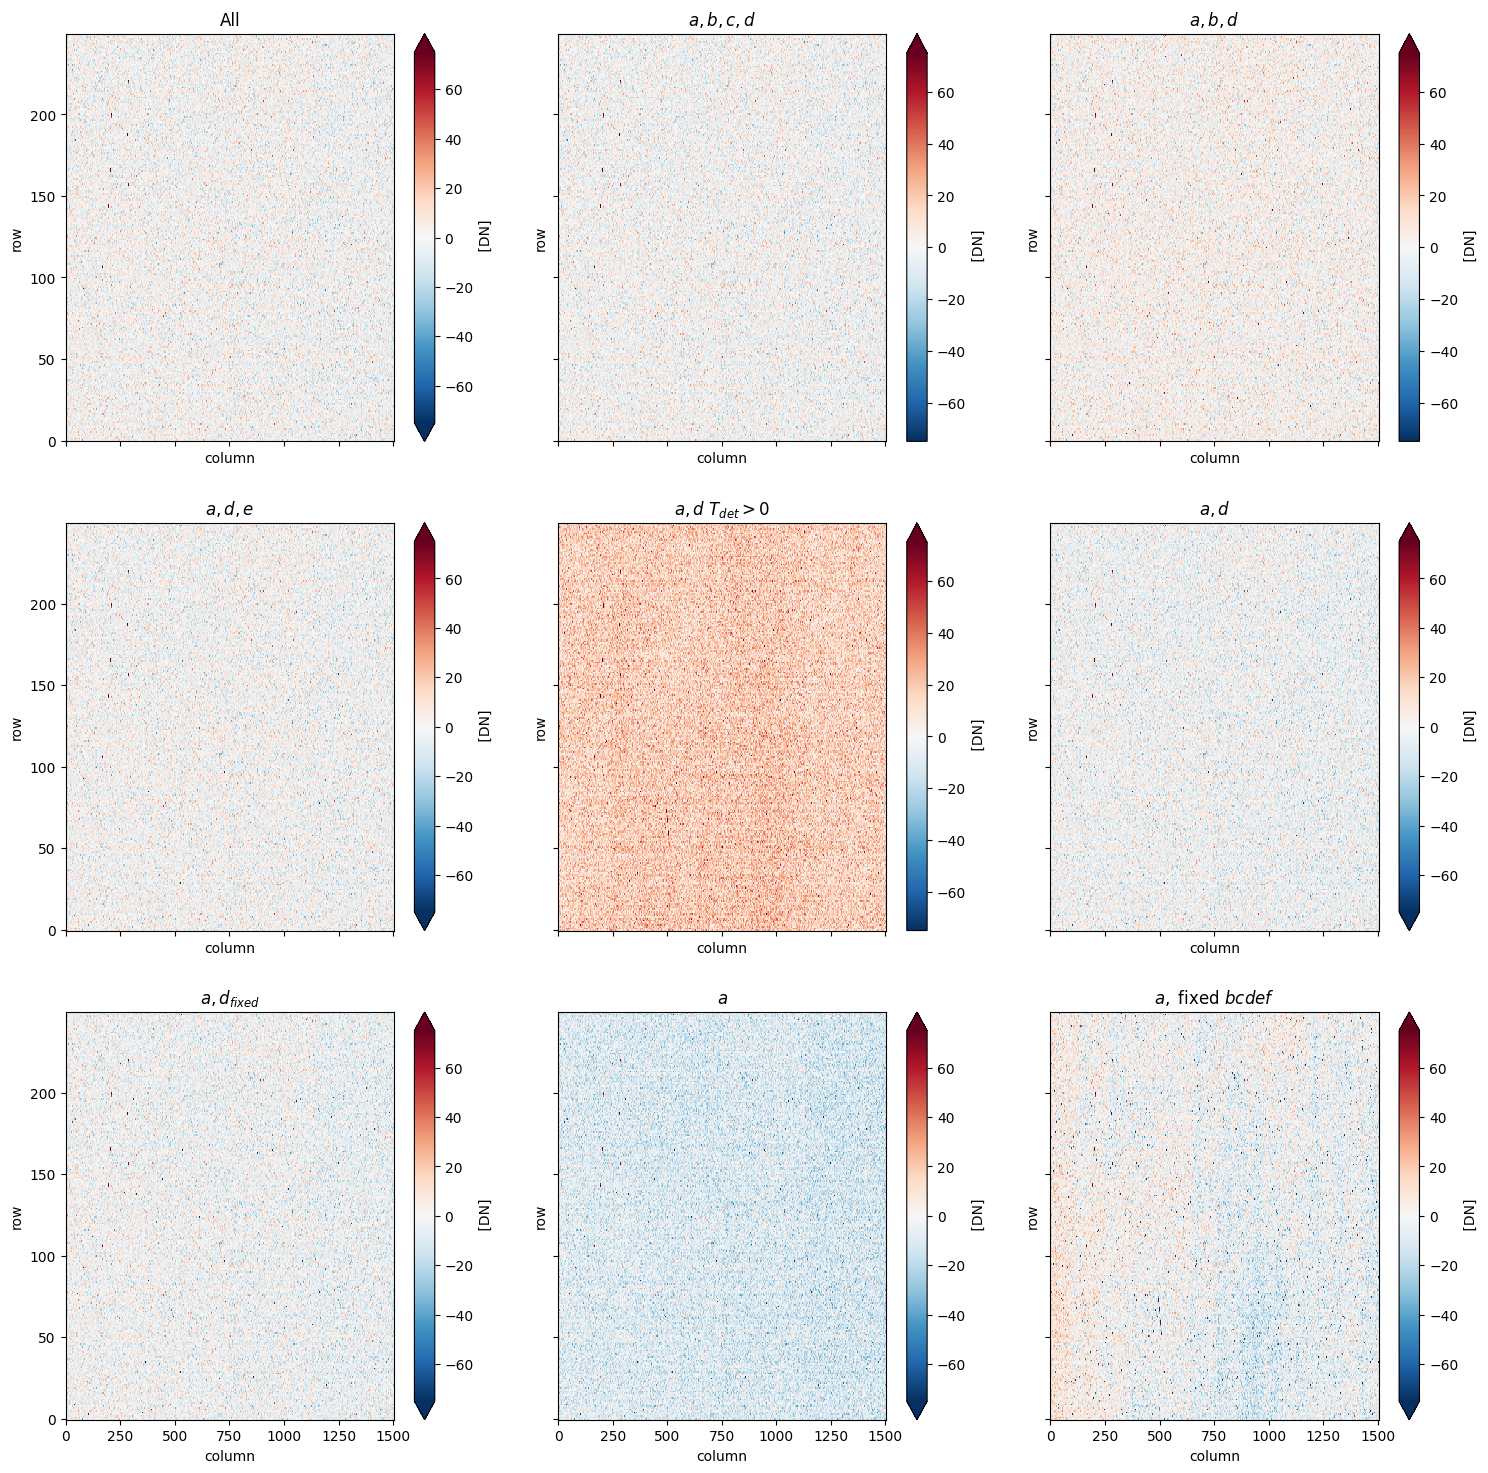

In [22]:
ncol = 3
nrow = 3
fig, axes = plt.subplots(nrow,ncol,figsize=(size*ncol,size*nrow),sharex=True,sharey=True)
norm = ImageNormalize(vmin=-75,vmax=75)
idx_sample = 1000
ped_rem_all[idx_sample,...].plot.imshow(ax=axes[0,0],norm=norm);axes[0,0].set_title('All')
ped_rem_abcd[idx_sample,...].plot.imshow(ax=axes[0,1],norm=norm);axes[0,1].set_title(r'$a,b,c,d$')
ped_rem_abd[idx_sample,...].plot.imshow(ax=axes[0,2],norm=norm);axes[0,2].set_title(r'$a,b,d$')
ped_rem_ade[idx_sample,...].plot.imshow(ax=axes[1,0],norm=norm);axes[1,0].set_title(r'$a,d,e$')
ped_rem_ad_warm[idx_sample,...].plot.imshow(ax=axes[1,1],norm=norm);axes[1,1].set_title(r'$a,d$ $T_{det}>0$')
ped_rem_ad[idx_sample,...].plot.imshow(ax=axes[1,2],norm=norm);axes[1,2].set_title(r'$a,d$')
ped_rem_a_fixed_d[idx_sample,...].plot.imshow(ax=axes[2,0],norm=norm);axes[2,0].set_title(r'$a,d_{fixed}$')
ped_rem_a[idx_sample,...].plot.imshow(ax=axes[2,1],norm=norm);axes[2,1].set_title(r'$a$')
ped_rem_a_fixed_bcdef[idx_sample,...].plot.imshow(ax=axes[2,2],norm=norm);axes[2,2].set_title(r'$a,$ fixed $bcdef$')
#axes[0].axes.set_aspect('equal')

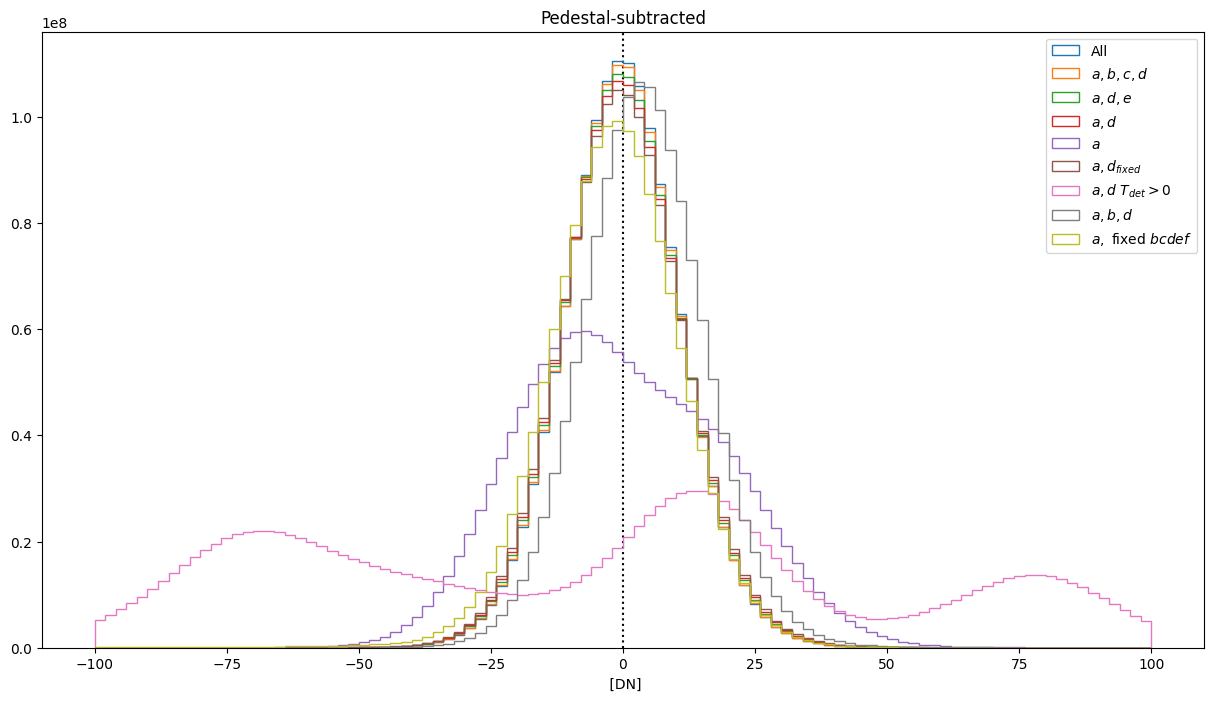

In [23]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot()
ax.axvline(x=0, ls=':', color='k');
_,be,_ = ped_rem_all.plot.hist(ax=ax,bins=100,range=(-100,100),histtype='step',log=False, label='All');
ped_rem_abcd.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,b,c,d$')
ped_rem_ade.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,d,e$')
ped_rem_ad.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,d$')
ped_rem_a.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a$');
ped_rem_a_fixed_d.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,d_{fixed}$');
ped_rem_ad_warm.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,d$ $T_{det}>0$');
ped_rem_abd.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,b,d$');
ped_rem_a_fixed_bcdef.plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,$ fixed $bcdef$');
ax.set_title('Pedestal-subtracted')
ax.legend()

In [24]:
is_warm = np.where(np.logical_and(ds.temperature_detector_0>0, ds.temperature_detector_1>0))
ds_warm = ds.isel(sample=is_warm[0])

In [28]:
pedestal_all_warm = pedestal_func(ds_warm, da_coeffs_all)
ped_rem_all_warm = ds_warm['data'] - pedestal_all_warm

In [26]:
pedestal_a_fixed_bcdef_warm = pedestal_func(ds_warm, da_coeffs_a_fixed_bcdef)
ped_rem_a_fixed_bcdef_warm = ds_warm['data'] - pedestal_a_fixed_bcdef_warm

Text(0.5, 1.0, '$a,$ fixed $bcdef$, $T>0$')

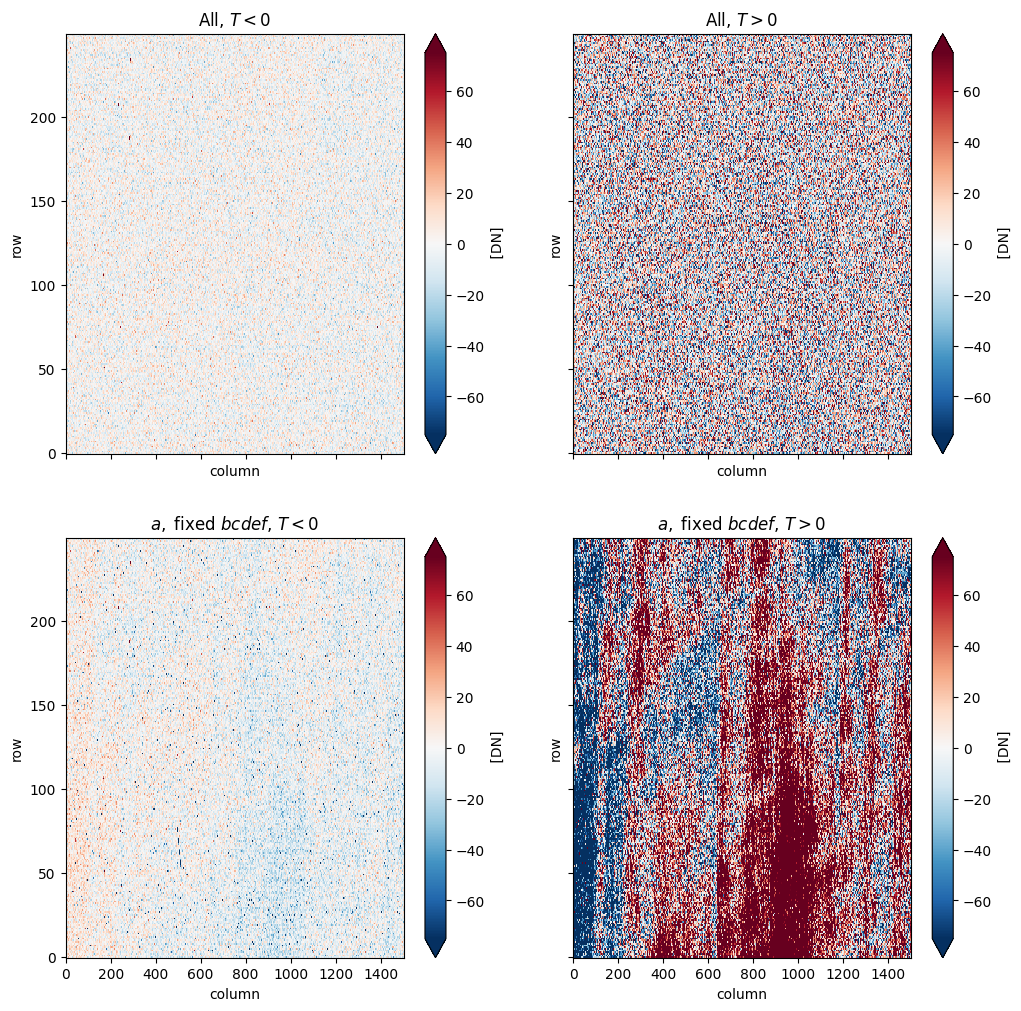

In [34]:
ncol = 2
nrow = 2
fig, axes = plt.subplots(nrow,ncol,figsize=(size*ncol,size*nrow),sharex=True,sharey=True)
norm = ImageNormalize(vmin=-75,vmax=75)
idx_sample_warm = 200
ped_rem_all[idx_sample,...].plot.imshow(ax=axes[0,0],norm=norm);axes[0,0].set_title(r'All, $T<0$')
ped_rem_all_warm[idx_sample_warm,...].plot.imshow(ax=axes[0,1],norm=norm);axes[0,1].set_title(r'All, $T>0$')
ped_rem_a_fixed_bcdef[idx_sample,...].plot.imshow(ax=axes[1,0],norm=norm);axes[1,0].set_title(r'$a,$ fixed $bcdef$, $T<0$')
ped_rem_a_fixed_bcdef_warm[idx_sample_warm,...].plot.imshow(ax=axes[1,1],norm=norm);axes[1,1].set_title(r'$a,$ fixed $bcdef$, $T>0$')
#axes[0].axes.set_aspect('equal')

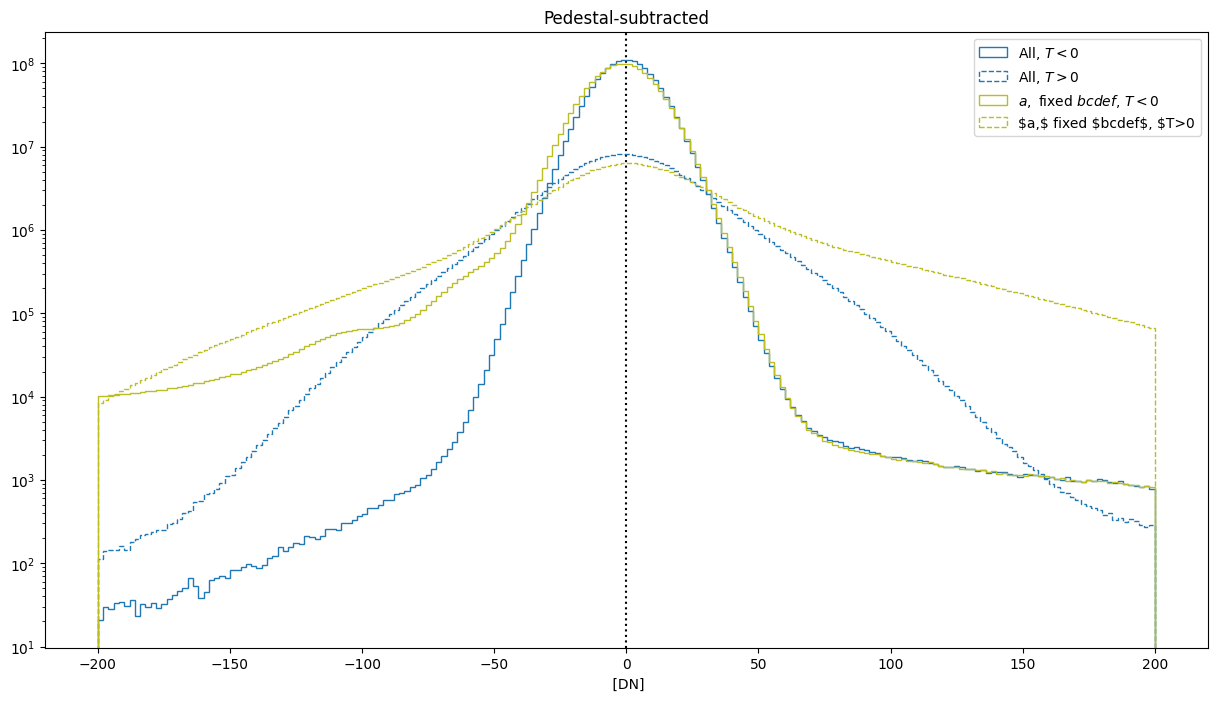

In [37]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot()
ax.axvline(x=0, ls=':', color='k');
_,be,_ = ped_rem_all.plot.hist(ax=ax,bins=200,range=(-200,200),histtype='step',log=False, label=r'All, $T<0$', color='C0');
ped_rem_all_warm.plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'All, $T>0$', color='C0', ls='--');
ped_rem_a_fixed_bcdef.plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,$ fixed $bcdef$, $T<0$', color='C8');
ped_rem_a_fixed_bcdef_warm.plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,$ fixed $bcdef$, $T>0', color='C8', ls='--');
ax.set_title('Pedestal-subtracted')
ax.set_yscale('log')
ax.legend()

I want to explore how the residuals vary as a function of increasing detector temperature

In [61]:
T_lower_limit = 10  # deg C
T_upper_limit = 15  # deg C
is_within_T_limits = np.where(np.logical_and(
    np.logical_and(ds.temperature_detector_0>T_lower_limit, ds.temperature_detector_0<T_upper_limit),
    np.logical_and(ds.temperature_detector_1>T_lower_limit, ds.temperature_detector_1<T_upper_limit)
))
ds_sublimit = ds.isel(sample=is_within_T_limits[0])

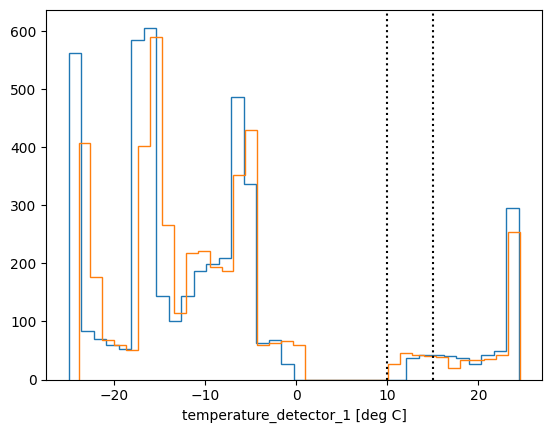

In [62]:
ds.temperature_detector_0.plot.hist(histtype='step', bins='fd');
ds.temperature_detector_1.plot.hist(histtype='step', bins='fd');
plt.axvline(x=T_lower_limit, color='k', ls=':')
plt.axvline(x=T_upper_limit, color='k', ls=':')

In [63]:
# This is the baseline
pedestal_baseline = pedestal_func(ds_sublimit, da_coeffs_all)
ped_rem_baseline = ds_sublimit['data'] - pedestal_baseline
# This is the experiment
pedestal_model = pedestal_func(ds_sublimit, da_coeffs_a_fixed_d)
ped_rem_model = ds_sublimit['data'] - pedestal_model

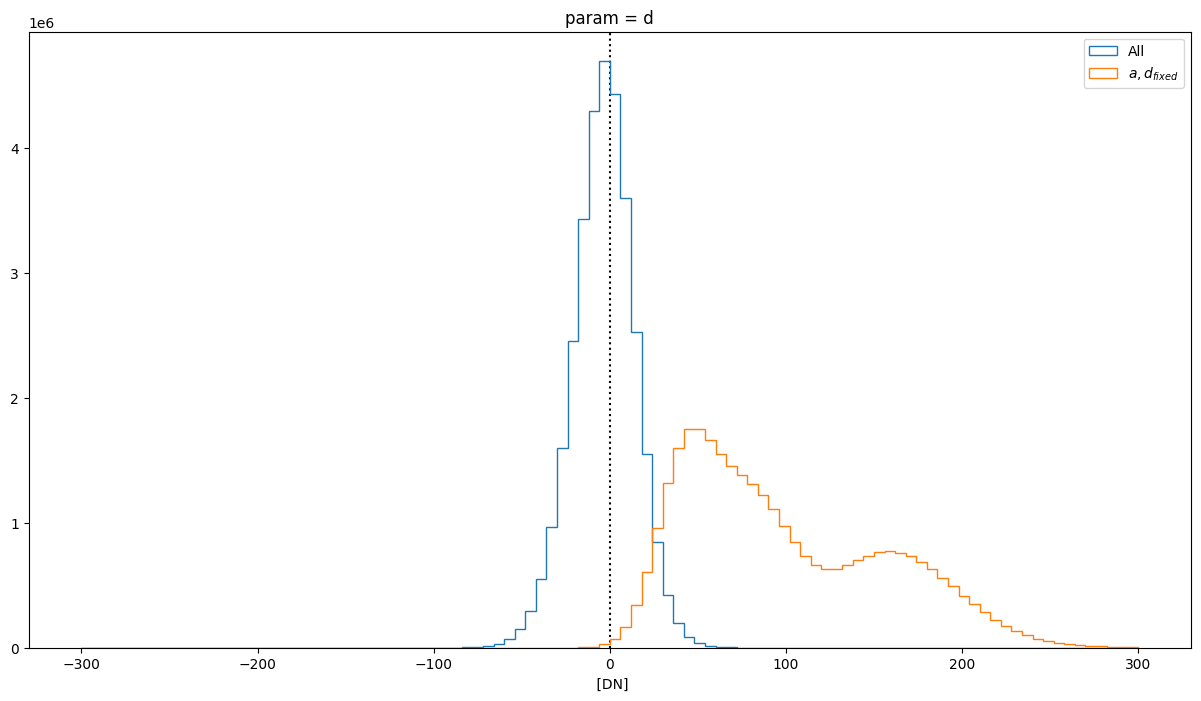

In [67]:
# Compare them
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot()
ax.axvline(x=0, ls=':', color='k');
_,be,_ = ped_rem_baseline.plot.hist(ax=ax,bins=100,range=(-300,300),histtype='step',log=False, label='All');
ped_rem_model.plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,d_{fixed}$');
ax.legend()

## Sandbox

Find the mean of $d$ in the $a,d$ model so that we can try to lock down $d$

In [7]:
import astropy.modeling.fitting
from astropy.modeling.models import Gaussian1D

(0.0, 5.0)

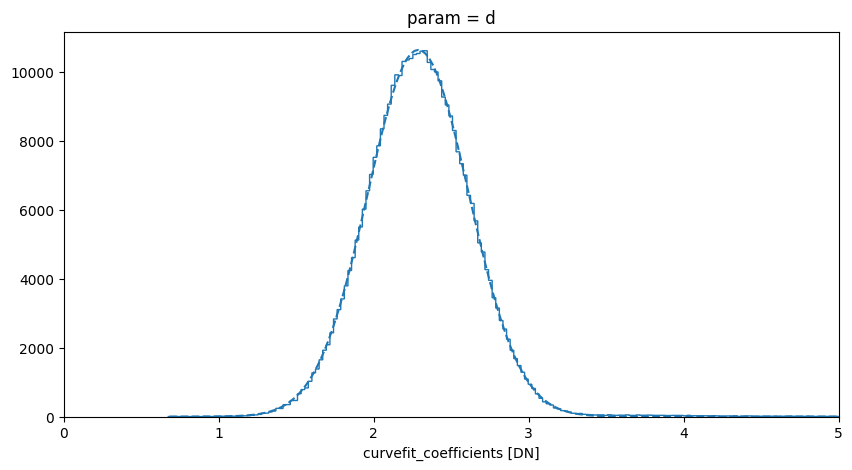

In [ ]:


plt.figure(figsize=(10,5))
y, xedge, patch = da_coeffs_ad.sel(param='d').plot.hist(bins='scott', histtype='step')
xmid = (xedge[1:] + xedge[:-1])/2
fitter = astropy.modeling.fitting.TRFLSQFitter()
ginit = Gaussian1D(amplitude=y.max(), mean=xmid[y.argmax()], stddev=0.5)
gfit = fitter(ginit, xmid, y)
plt.plot(xmid, gfit(xmid), color=patch[0].get_edgecolor(), ls='--')
plt.xlim(0,5)

In [12]:
gfit.mean.value

np.float64(2.288023013652479)

Fit a Guassian to the $b-e$ parameters to lock them down to the mean

In [25]:
da_coeffs_all_all_pixels = xarray.open_dataarray(data_dir / 'fit_coefficients.nc').compute()

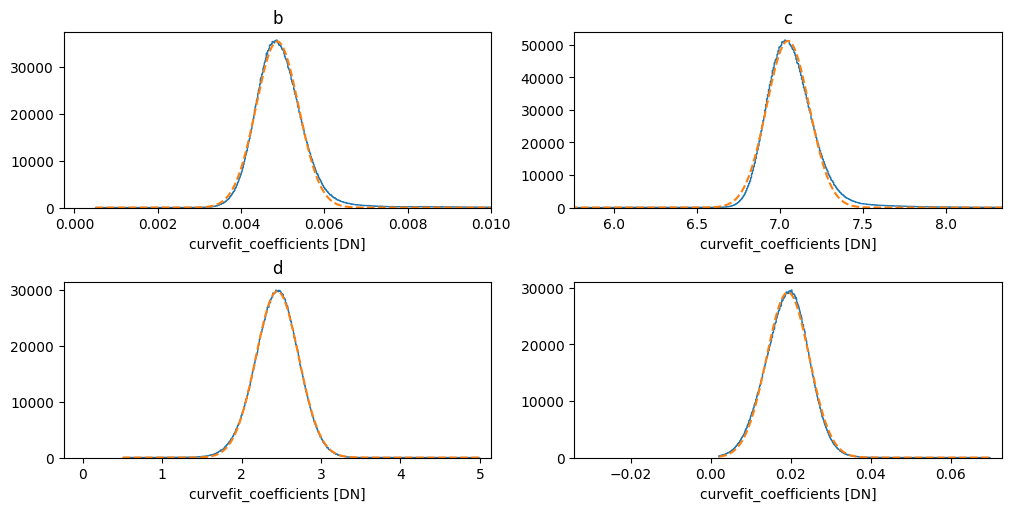

In [35]:
fig, axes = plt.subplots(2,2,figsize=(10,5), layout='constrained')

fixed_param_values = {}
for ax,p in zip(axes.flatten(),['b', 'c', 'd', 'e']):
    y, xedge, patch = da_coeffs_all_all_pixels.sel(param=p).plot.hist(bins='scott', range=range_dict[p], histtype='step', ax=ax)
    xmid = (xedge[1:] + xedge[:-1])/2
    fitter = astropy.modeling.fitting.TRFLSQFitter()
    ginit = Gaussian1D(amplitude=y.max(), mean=xmid[y.argmax()], stddev=0.005)
    gfit = fitter(ginit, xmid, y)
    fixed_param_values[p] = gfit.mean.value
    ax.plot(xmid, gfit(xmid), ls='--', color='C1')
    ax.set_title(p)
    ax.set_xlim(gfit.mean - 10*gfit.stddev, gfit.mean + 10*gfit.stddev)

In [37]:
fixed_param_values

{'b': np.float64(0.0048736182432977115),
 'c': np.float64(7.047611800096444),
 'd': np.float64(2.4490954061290844),
 'e': np.float64(0.01927927292177515)}

In [38]:
da_coeffs_all_all_pixels.sel(param=p)

<xarray.DataArray 'curvefit_coefficients' (row: 2000, column: 1504)> Size: 24MB
array([[0.02472269, 0.02900516, 0.02352331, ..., 0.01479828, 0.02232543,
        0.0187084 ],
       [0.0097447 , 0.01529528, 0.01062908, ..., 0.01051421, 0.01137741,
        0.0081379 ],
       [0.02519883, 0.02113239, 0.01623695, ..., 0.01141039, 0.01596207,
        0.00799236],
       ...,
       [0.04105995, 0.03564075, 0.02952949, ..., 0.02483363, 0.01738968,
        0.01496131],
       [0.0330876 , 0.03757871, 0.0284679 , ..., 0.01193302, 0.01815331,
        0.00592358],
       [0.0495046 , 0.0367428 , 0.03902557, ..., 0.00987355, 0.0128283 ,
        0.01270305]], shape=(2000, 1504))
Coordinates:
    param    <U1 4B 'e'
Dimensions without coordinates: row, column
Attributes:
    unit:     DN

In [39]:
2000*1504

3008000